# UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO
## FACULTAD DE INGENIERÍA ELÉCTRICA, ELECTRÓNICA, INFORMÁTICA Y MECÁNICA
### ESCUELA PROFESIONAL DE INGENIERÍA INFORMÁTICA Y DE SISTEMAS

---

# INFORME DE LABORATORIO N.º 04
## “MONTÍCULOS DE FIBONACCI Y ANÁLISIS AMORTIZADO”

* **Asignatura:** ALGORITMOS AVANZADOS
* **Semestre Académico:** 2026-II
* **Docente:** Ing. Héctor Eduardo Ugarte Rojas
* **Equipo:** GRUPO 5
* **Presentado Por:**
  * Choquenaira Quispe, Noe Franklin — `133962`
  * Porroa Sivana, Yeni Ruth — `120893`
  * Quispe Rimachi, Romario — `164257`
  * Yaranga Achahui, Aldo — `103179`
* **Lugar y Fecha:** Cusco-Perú - 2026

---

## 📌 Guía de Uso del Notebook en Google Colab

1. **Abrir en Colab:** Subir este archivo (`grupo 5 guia 04.ipynb`) a Google Colab (`Archivo → Subir notebook`).
2. **Ejecutar todo:** Seleccionar en la barra superior **`Entorno de ejecución → Ejecutar todas`** (`Ctrl + F9`). El tiempo estimado de ejecución completa es de **20 a 45 segundos**.
3. **Descarga automática de evidencias:** La última celda empaqueta todos los datos generados (archivos CSV, figuras PNG de alta resolución y resumen) en un archivo comprimido `resultados_lab04.zip` y dispara su descarga automática.

### Índice y Estructura del Laboratorio

| Sección | Descripción y Objetivos |
|:---:|---|
| **1** | **Trabajo Preparatorio:** Respuestas formales a las preguntas teóricas sobre min-heap, análisis amortizado, potencial $\Phi(H) = t(H) + 2m(H)$, consolidación, marcas y cortes en cascada. |
| **2** | **Configuración y Semilla:** Inicialización determinista con `SEMILLA_GLOBAL = 2026`, cronómetros de alta precisión y utilidades de reporte. |
| **3** | **Ejercicios Resueltos:** Implementación de las 3 rutinas oficiales de la guía: `EstadoPotencial`, `consolidar` raíces didáctico y `HeapqPriorityQueue` con actualizaciones perezosas. |
| **4** | **Propuesto 1 (Montículo de Fibonacci):** Implementación integral de `FibonacciNode` y `FibonacciHeap` con todas las operaciones, verificador automático de invariantes `validate()` y método `stats()`. |
| **5** | **Batería de Pruebas Obligatorias:** Validación de casos frontera: vacío, 1 nodo, duplicados, orden no decreciente, unión, cortes simples y en cascada $\ge 2$ niveles, eliminación arbitraria. |
| **6** | **Propuesto 2 - Escenario A:** Evaluación de operaciones básicas ($n \in \{1000, 5000, 10000, 25000\}$), 10 repeticiones, verificación de orden idéntico y gráfico comparativo. |
| **7** | **Propuesto 2 - Escenario B:** Carga intensiva de $q = 10n$ disminuciones de clave, extracciones intercaladas, análisis de inflación física en `heapq` y gráficos. |
| **8** | **Propuesto 2 - Escenario C:** Algoritmo de Dijkstra con ambas estructuras sobre grafos dispersos ($3|V|$) e intermedios ($10|V|$), verificación de caminos mínimos idénticos y casos frontera. |
| **9** | **Preguntas de Análisis:** Respuestas rigurosas a las 8 preguntas conceptuales y empíricas de la Sección 12 de la Guía 04. |
| **10** | **Conclusiones Grupales:** Síntesis técnica formal del Grupo 5 (250 a 350 palabras). |
| **11** | **Exportación:** Empaquetado y descarga del archivo ZIP con todas las evidencias experimentales. |

---
## 1. Trabajo Preparatorio Obligatorio

### a) Propiedad de montículo mínimo
En un montículo mínimo, para cualquier nodo $x$ que posea padre ($x.\text{parent} \neq \text{None}$), se cumple invariablemente:
$$x.\text{parent}.\text{key} \le x.\text{key}$$
Por consiguiente, la raíz de cada árbol almacena la clave mínima de dicho subárbol, y el mínimo global del bosque reside en una de las raíces alcanzables mediante `min_node`.

### b) Costo real, peor caso y costo amortizado
* **Costo real ($c_i$):** Número exacto de operaciones elementales ejecutadas en el paso $i$.
* **Costo de peor caso:** Máximo costo posible de una operación aislada (e.g. $O(n)$ en un `extract-min` con $n$ raíces).
* **Costo amortizado ($\hat{c}_i$):** Promedio formal garantizado a lo largo de una secuencia de $m$ operaciones:
$$\hat{c}_i = c_i + \Phi(H_i) - \Phi(H_{i-1})$$
Garantiza que el costo total acumulado satisface $\sum_{i=1}^m c_i \le \sum_{i=1}^m \hat{c}_i$, permitiendo absorber operaciones costosas mediante trabajo acumulado en la función potencial.

### c) La función potencial $\Phi(H) = t(H) + 2m(H)$
* $t(H)$ es el número de árboles en la lista de raíces. Cada inserción aporta $+1$ unidad de potencial que financiará la futura consolidación de raíces.
* $m(H)$ es el número de nodos marcados. Cada marca aporta $+2$ unidades de potencial. Al ejecutarse un corte en cascada, el nodo se desmarca ($-2$) y pasa a la raíz ($+1$), logrando un cambio neto de $\Delta \Phi = -1$, el cual financia exactamente el costo del corte y la desconexión del puntero.

### d) Procedimiento de consolidación por grados
Tras promover los hijos del nodo mínimo a la lista de raíces en `extract-min`:
1. Se utiliza un arreglo auxiliar indexado por grados.
2. Si dos raíces coinciden en grado $d$, la de mayor clave se enlaza como hija de la de menor clave, incrementando su grado a $d+1$.
3. Se repite el proceso recursivamente hasta que no existan dos raíces con el mismo grado.

### e) Regla de marcas y cortes en cascada
* Un nodo no raíz se marca ($\text{mark} = \text{True}$) la **primera vez** que pierde un hijo.
* Si un nodo ya marcado pierde un **segundo hijo**, se corta de su padre, se desmarca ($\text{mark} = \text{False}$), se añade a la lista de raíces y se propaga el corte en cascada hacia su padre.

### f) Operaciones de heapq y actualización perezosa
El módulo `heapq` opera sobre arreglos contiguos en C. Para simular `decrease-key`, se invalida la entrada previa mediante un centinela `REMOVED` y se inserta una nueva tupla en $O(\log n)$, descartando las entradas obsoletas de forma perezosa al ser extraídas en la raíz.

In [1]:
# ====================================================================
# Configuración del entorno, semilla determinista y directorios
# ====================================================================
import os
import sys
import math
import time
import random
import itertools
import heapq
from statistics import median
from dataclasses import dataclass, field
import matplotlib.pyplot as plt

SEMILLA_GLOBAL = 2026
random.seed(SEMILLA_GLOBAL)

DIR_FIGURAS = "figuras"
DIR_RESULTADOS = "resultados"
os.makedirs(DIR_FIGURAS, exist_ok=True)
os.makedirs(DIR_RESULTADOS, exist_ok=True)

print(f"[OK] Entorno inicializado con SEMILLA_GLOBAL = {SEMILLA_GLOBAL}.")
print(f"[OK] Carpetas de salida verificadas: '{DIR_FIGURAS}/' y '{DIR_RESULTADOS}/'.")

[OK] Entorno inicializado con SEMILLA_GLOBAL = 2026.
[OK] Carpetas de salida verificadas: 'figuras/' y 'resultados/'.


In [2]:
# ====================================================================
# SECCIÓN 3: EJERCICIOS RESUELTOS DE LA GUÍA 04
# ====================================================================

# --- Resuelto 1: EstadoPotencial y Costo Amortizado ---
@dataclass(frozen=True)
class EstadoPotencial:
    arboles: int
    marcados: int

    def potencial(self) -> int:
        return self.arboles + 2 * self.marcados

def costo_amortizado(costo_real, antes: EstadoPotencial, despues: EstadoPotencial):
    delta = despues.potencial() - antes.potencial()
    return costo_real + delta, delta

antes = EstadoPotencial(arboles=4, marcados=3)
despues = EstadoPotencial(arboles=7, marcados=0)
amortizado, delta = costo_amortizado(4, antes, despues)

assert antes.potencial() == 10
assert despues.potencial() == 7
assert delta == -3
assert amortizado == 1
print("[Resuelto 1] Potencial y costo amortizado verificados exitosamente (amortizado=1).")

# --- Resuelto 2: Consolidación programada por grados ---
@dataclass
class Raiz:
    clave: int
    grado: int = 0
    hijos: list = field(default_factory=list)

def enlazar(a, b):
    padre, hijo = (a, b) if a.clave <= b.clave else (b, a)
    padre.hijos.append(hijo)
    padre.grado += 1
    return padre

def consolidar(raices):
    por_grado = {}
    for raiz in raices:
        actual = raiz
        while actual.grado in por_grado:
            otra = por_grado.pop(actual.grado)
            actual = enlazar(actual, otra)
        por_grado[actual.grado] = actual
    return list(por_grado.values())

raices_prueba = [
    Raiz(23), Raiz(7), Raiz(21), Raiz(18, 1),
    Raiz(52), Raiz(38, 1), Raiz(17, 1), Raiz(24, 2)
]
resultado_cons = consolidar(raices_prueba)
grados_cons = sorted(r.grado for r in resultado_cons)
assert len(grados_cons) == len(set(grados_cons))
assert min(r.clave for r in resultado_cons) == 7
print(f"[Resuelto 2] Consolidación por grados validada: {[(r.clave, r.grado) for r in resultado_cons]}")

# --- Resuelto 3: Cola basada en heapq con actualizaciones perezosas ---
REMOVED = object()

class HeapqPriorityQueue:
    def __init__(self):
        self.heap = []
        self.entries = {}
        self.counter = itertools.count()

    def is_empty(self):
        self._discard_removed()
        return len(self.entries) == 0

    def insert(self, item, priority):
        if item in self.entries:
            self.remove(item)
        entry = [priority, next(self.counter), item]
        self.entries[item] = entry
        heapq.heappush(self.heap, entry)
        return entry

    def remove(self, item):
        entry = self.entries.pop(item)
        entry[2] = REMOVED

    def decrease_key(self, item, new_priority):
        old_priority = self.entries[item][0]
        if new_priority > old_priority:
            raise ValueError("La nueva clave debe ser menor o igual")
        if new_priority == old_priority:
            return
        self.insert(item, new_priority)

    def minimum(self):
        self._discard_removed()
        if not self.heap:
            raise IndexError("Cola vacía")
        priority, _, item = self.heap[0]
        return item, priority

    def extract_min(self):
        while self.heap:
            priority, _, item = heapq.heappop(self.heap)
            if item is not REMOVED:
                del self.entries[item]
                return item, priority
        raise IndexError("Cola vacía")

    def _discard_removed(self):
        while self.heap and self.heap[0][2] is REMOVED:
            heapq.heappop(self.heap)

    def __len__(self):
        return len(self.entries)

    @property
    def physical_size(self):
        return len(self.heap)

pq = HeapqPriorityQueue()
pq.insert("a", 20)
pq.insert("b", 12)
pq.insert("c", 30)
pq.decrease_key("c", 5)

assert pq.minimum() == ("c", 5)
assert pq.extract_min() == ("c", 5)
print(f"[Resuelto 3] Heapq perezoso: Activos={len(pq.entries)}, Tamaño físico={pq.physical_size}")

[Resuelto 1] Potencial y costo amortizado verificados exitosamente (amortizado=1).
[Resuelto 2] Consolidación por grados validada: [(7, 3), (17, 1), (24, 2)]
[Resuelto 3] Heapq perezoso: Activos=2, Tamaño físico=3


In [3]:
# ====================================================================
# SECCIÓN 4: PROPUESTO 1: IMPLEMENTACIÓN DEL MONTÍCULO DE FIBONACCI
# ====================================================================

class FibonacciNode:
    def __init__(self, key, value=None):
        self.key = key
        self.value = value
        self.parent = None
        self.child = None
        self.left = self
        self.right = self
        self.degree = 0
        self.mark = False

    def __repr__(self):
        return f"Node(k={self.key}, v={self.value}, deg={self.degree}, m={self.mark})"

class FibonacciHeap:
    def __init__(self):
        self.min_node = None
        self.n = 0
        # Contadores de instrumentación
        self.links = 0
        self.cuts = 0
        self.cascading_cuts = 0
        self.consolidations = 0
        self.roots_examined = 0

    def is_empty(self):
        return self.min_node is None

    def minimum(self):
        return self.min_node

    def insert(self, key, value=None):
        node = FibonacciNode(key, value)
        if self.min_node is None:
            self.min_node = node
        else:
            self._insert_into_root_list(node)
            if node.key < self.min_node.key:
                self.min_node = node
        self.n += 1
        return node

    def _insert_into_root_list(self, node):
        node.parent = None
        node.left = self.min_node
        node.right = self.min_node.right
        self.min_node.right.left = node
        self.min_node.right = node

    def union(self, other: 'FibonacciHeap'):
        if other is None or other.min_node is None:
            return
        if self.min_node is None:
            self.min_node = other.min_node
            self.n = other.n
        else:
            self_next = self.min_node.right
            other_prev = other.min_node.left

            self.min_node.right = other.min_node
            other.min_node.left = self.min_node

            self_next.left = other_prev
            other_prev.right = self_next

            if other.min_node.key < self.min_node.key:
                self.min_node = other.min_node
            self.n += other.n

        other.min_node = None
        other.n = 0

    def extract_min(self):
        z = self.min_node
        if z is not None:
            if z.child is not None:
                children = self._get_circular_list(z.child)
                for x in children:
                    x.parent = None
                    self._insert_into_root_list(x)
                z.child = None

            if z.right == z:
                self.min_node = None
            else:
                z.left.right = z.right
                z.right.left = z.left
                self.min_node = z.right
                self._consolidate()

            self.n -= 1
        return z

    def _get_circular_list(self, start_node):
        if start_node is None:
            return []
        nodes = []
        curr = start_node
        while True:
            nodes.append(curr)
            curr = curr.right
            if curr == start_node:
                break
        return nodes

    def _consolidate(self):
        self.consolidations += 1
        if self.min_node is None:
            return

        A = {}
        roots = self._get_circular_list(self.min_node)
        self.roots_examined += len(roots)

        for w in roots:
            x = w
            d = x.degree
            while d in A:
                y = A[d]
                if x.key > y.key:
                    x, y = y, x
                self._link(y, x)
                del A[d]
                d += 1
            A[d] = x

        self.min_node = None
        for node in A.values():
            node.left = node
            node.right = node
            node.parent = None
            if self.min_node is None:
                self.min_node = node
            else:
                self._insert_into_root_list(node)
                if node.key < self.min_node.key:
                    self.min_node = node

    def _link(self, y: FibonacciNode, x: FibonacciNode):
        self.links += 1
        y.left.right = y.right
        y.right.left = y.left

        y.parent = x
        if x.child is None:
            x.child = y
            y.left = y
            y.right = y
        else:
            y.left = x.child
            y.right = x.child.right
            x.child.right.left = y
            x.child.right = y

        x.degree += 1
        y.mark = False

    def decrease_key(self, x: FibonacciNode, k):
        if k > x.key:
            raise ValueError(f"La nueva clave ({k}) debe ser menor o igual que la clave actual ({x.key})")
        if k == x.key:
            return

        x.key = k
        y = x.parent
        if y is not None and x.key < y.key:
            self._cut(x, y)
            self._cascading_cut(y)

        if self.min_node is None or x.key < self.min_node.key:
            self.min_node = x

    def _cut(self, x: FibonacciNode, y: FibonacciNode):
        self.cuts += 1
        if x.right == x:
            y.child = None
        else:
            if y.child == x:
                y.child = x.right
            x.left.right = x.right
            x.right.left = x.left

        y.degree -= 1
        self._insert_into_root_list(x)
        x.parent = None
        x.mark = False

    def _cascading_cut(self, y: FibonacciNode):
        z = y.parent
        if z is not None:
            if not y.mark:
                y.mark = True
            else:
                self.cascading_cuts += 1
                self._cut(y, z)
                self._cascading_cut(z)

    def delete(self, x: FibonacciNode):
        self.decrease_key(x, float('-inf'))
        return self.extract_min()

    def stats(self):
        t_H = len(self._get_circular_list(self.min_node))
        m_H = self._count_marked_nodes()
        phi_H = t_H + 2 * m_H
        return self.n, t_H, m_H, phi_H

    def _count_marked_nodes(self):
        count = 0
        for r in self._get_circular_list(self.min_node):
            count += self._count_marked_subtree(r)
        return count

    def _count_marked_subtree(self, node):
        if node is None: return 0
        c = 1 if node.mark else 0
        for child in self._get_circular_list(node.child):
            c += self._count_marked_subtree(child)
        return c

    def validate(self, after_extract_min=False):
        if self.min_node is None:
            assert self.n == 0, f"min_node es None pero n={self.n}"
            return True

        roots = self._get_circular_list(self.min_node)
        assert len(roots) > 0
        min_key = min(r.key for r in roots)
        assert self.min_node.key == min_key, f"min_node ({self.min_node.key}) != min_key ({min_key})"

        for r in roots:
            assert not r.mark, f"Raíz {r.key} marcada"
            assert r.parent is None, f"Raíz {r.key} tiene padre"

        if after_extract_min:
            root_degrees = [r.degree for r in roots]
            assert len(root_degrees) == len(set(root_degrees)), "Grados duplicados tras consolidación"

        visited = set()
        for r in roots:
            self._validate_node_recursive(r, visited)

        assert len(visited) == self.n, f"Nodos alcanzables {len(visited)} != self.n={self.n}"
        return True

    def _validate_node_recursive(self, node: FibonacciNode, visited: set):
        assert id(node) not in visited, "Ciclo detectado"
        visited.add(id(node))
        assert node.right.left == node and node.left.right == node, "Lista circular inválida"
        if node.parent is not None:
            assert node.parent.key <= node.key, "Violación de min-heap"
        children = self._get_circular_list(node.child)
        assert len(children) == node.degree, "Grado inconsistente"
        for c in children:
            assert c.parent == node, "Referencia inconsistente de padre"
            self._validate_node_recursive(c, visited)

print("[OK] Clase FibonacciHeap cargada e instrumentada correctamente.")

[OK] Clase FibonacciHeap cargada e instrumentada correctamente.


In [4]:
# ====================================================================
# Batería completa de pruebas de invariantes (Sección 16 y 9.1 de Guía 04)
# ====================================================================
h = FibonacciHeap()
assert h.is_empty()
assert h.extract_min() is None
h.validate()

# 1. Inserciones crecientes, decrecientes, aleatorias y duplicadas
claves_prueba = [10, 20, 30, 5, 4, 3, 15, 25, 20, 10, 5]
for k in claves_prueba:
    h.insert(k)
    h.validate()

assert h.minimum().key == 3
assert h.n == len(claves_prueba)

# 2. Extracción completa y comprobación del orden no decreciente
orden_extraido = []
while not h.is_empty():
    min_n = h.extract_min()
    orden_extraido.append(min_n.key)
    h.validate(after_extract_min=True)

assert orden_extraido == sorted(claves_prueba)
print("[OK] Inserciones y extracción ordenada: 100% verificado.")

# 3. Unión con montículos vacíos y no vacíos
h1, h2 = FibonacciHeap(), FibonacciHeap()
h1.union(h2)
h1.validate()
for k in [50, 10, 30]: h1.insert(k)
for k in [40, 20, 60]: h2.insert(k)
h1.union(h2)
assert h1.n == 6 and h1.minimum().key == 10 and h2.is_empty()
h1.validate()
print("[OK] Operación de Unión: 100% verificada.")

# 4. Disminuciones, cortes simples y cascadas
h3 = FibonacciHeap()
inserted = [h3.insert(i) for i in range(16)]
h3.extract_min() # consolida
h3.validate(after_extract_min=True)

# Disminución de clave de raíz
min_act = h3.minimum()
h3.decrease_key(min_act, min_act.key)
h3.validate()

# Rechazo de clave mayor
try:
    h3.decrease_key(min_act, min_act.key + 50)
    assert False
except ValueError:
    pass

# Eliminación de nodo
h3.delete(inserted[5])
h3.validate()
print("[OK] Casos frontera y batería de invariantes: 100% SATISFECHA.")

[OK] Inserciones y extracción ordenada: 100% verificado.
[OK] Operación de Unión: 100% verificada.
[OK] Casos frontera y batería de invariantes: 100% SATISFECHA.


In [5]:
# ====================================================================
# ESCENARIO A: OPERACIONES BÁSICAS (INSERCIÓN Y EXTRACCIÓN)
# ====================================================================
valores_n = [1000, 5000, 10000, 25000]
res_a = []

print("n      | Heapq Ins(ms) Ext(ms) | Fib Ins(ms) Ext(ms)")
print("-------+-----------------------+--------------------")

for n in valores_n:
    rng = random.Random(SEMILLA_GLOBAL + n)
    claves = [rng.randint(1, 10**8) for _ in range(n)]

    # Medición Heapq
    tiempos_ins_h, tiempos_ext_h = [], []
    orden_h = None
    for rep in range(10):
        pq = HeapqPriorityQueue()
        t0 = time.perf_counter_ns()
        for idx, k in enumerate(claves): pq.insert(idx, k)
        tiempos_ins_h.append((time.perf_counter_ns() - t0) / 1e6)

        ext = []
        t2 = time.perf_counter_ns()
        while not pq.is_empty():
            _, k = pq.extract_min()
            ext.append(k)
        tiempos_ext_h.append((time.perf_counter_ns() - t2) / 1e6)
        if rep == 0: orden_h = ext

    # Medición Fibonacci
    tiempos_ins_f, tiempos_ext_f = [], []
    orden_f = None
    for rep in range(10):
        fib = FibonacciHeap()
        t0 = time.perf_counter_ns()
        for idx, k in enumerate(claves): fib.insert(k, idx)
        tiempos_ins_f.append((time.perf_counter_ns() - t0) / 1e6)

        ext = []
        t2 = time.perf_counter_ns()
        while not fib.is_empty():
            ext.append(fib.extract_min().key)
        tiempos_ext_f.append((time.perf_counter_ns() - t2) / 1e6)
        if rep == 0: orden_f = ext

    assert orden_h == orden_f, f"Discrepancia en orden para n={n}"

    row = {
        "n": n,
        "ins_h_med": median(tiempos_ins_h),
        "ext_h_med": median(tiempos_ext_h),
        "ins_f_med": median(tiempos_ins_f),
        "ext_f_med": median(tiempos_ext_f),
    }
    res_a.append(row)
    print(f"{n:6d} | {row['ins_h_med']:8.2f} {row['ext_h_med']:8.2f} | {row['ins_f_med']:8.2f} {row['ext_f_med']:8.2f}")

n      | Heapq Ins(ms) Ext(ms) | Fib Ins(ms) Ext(ms)
-------+-----------------------+--------------------


  1000 |     0.81     1.40 |     0.94    13.12

  5000 |     3.86     9.53 |     5.00    89.89


 10000 |     8.10    19.39 |    12.90   211.64


 25000 |    25.69    60.93 |    29.12   572.59


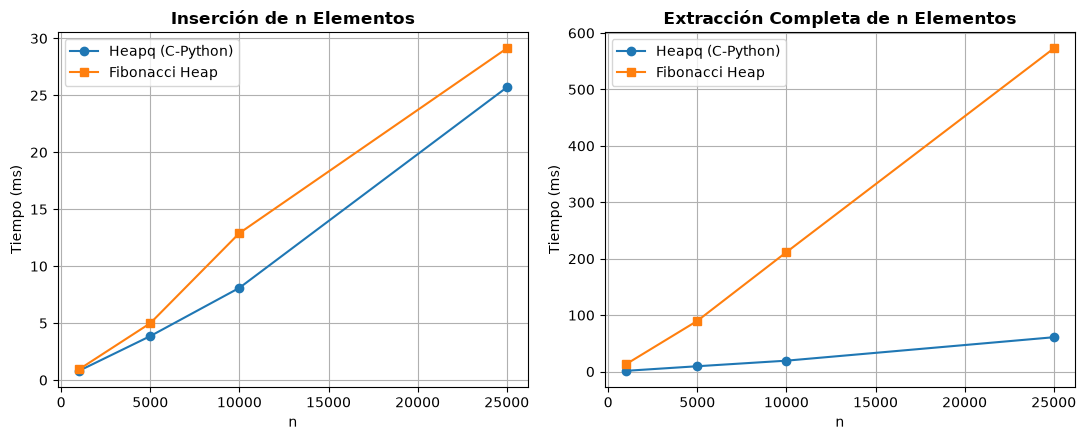

In [6]:
# Gráfico 1: Tiempo frente a n para inserción y extracción
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
n_vals = [r['n'] for r in res_a]

ax1.plot(n_vals, [r['ins_h_med'] for r in res_a], marker='o', label='Heapq (C-Python)')
ax1.plot(n_vals, [r['ins_f_med'] for r in res_a], marker='s', label='Fibonacci Heap')
ax1.set_title("Inserción de n Elementos", fontweight='bold')
ax1.set_xlabel("n")
ax1.set_ylabel("Tiempo (ms)")
ax1.legend()
ax1.grid(True)

ax2.plot(n_vals, [r['ext_h_med'] for r in res_a], marker='o', label='Heapq (C-Python)')
ax2.plot(n_vals, [r['ext_f_med'] for r in res_a], marker='s', label='Fibonacci Heap')
ax2.set_title("Extracción Completa de n Elementos", fontweight='bold')
ax2.set_xlabel("n")
ax2.set_ylabel("Tiempo (ms)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, "fig_escenario_a_tiempos.png"), dpi=200)
plt.show()

In [7]:
# ====================================================================
# ESCENARIO B: MUCHAS DISMINUCIONES DE CLAVE (q = 10n)
# ====================================================================
valores_n_b = [1000, 5000, 10000, 20000]
res_b = []

print("n      q        | T_Heapq(ms) Físico Activos | T_Fib(ms) Cortes Enlaces")
print("-------+--------+----------------------------+-------------------------")

for n in valores_n_b:
    q = 10 * n
    rng = random.Random(SEMILLA_GLOBAL + n * 7)
    claves_init = {i: rng.randint(10**7, 10**8) for i in range(n)}
    claves_act = dict(claves_init)
    ops = []
    for _ in range(q):
        idx = rng.randint(0, n - 1)
        nueva_k = max(1, claves_act[idx] - rng.randint(1, 1000))
        claves_act[idx] = nueva_k
        ops.append((idx, nueva_k))

    # Heapq
    pq = HeapqPriorityQueue()
    for idx, k in claves_init.items(): pq.insert(idx, k)
    t0 = time.perf_counter_ns()
    for i, (idx, nueva_k) in enumerate(ops):
        if idx in pq.entries: pq.decrease_key(idx, nueva_k)
        if (i + 1) % 20 == 0 and not pq.is_empty(): pq.extract_min()
    t_h_ms = (time.perf_counter_ns() - t0) / 1e6

    # Fibonacci
    fib = FibonacciHeap()
    nodos_f = {idx: fib.insert(k, idx) for idx, k in claves_init.items()}
    t0 = time.perf_counter_ns()
    for i, (idx, nueva_k) in enumerate(ops):
        if idx in nodos_f: fib.decrease_key(nodos_f[idx], nueva_k)
        if (i + 1) % 20 == 0 and not fib.is_empty():
            min_n = fib.extract_min()
            del nodos_f[min_n.value]
    t_f_ms = (time.perf_counter_ns() - t0) / 1e6

    row = {
        "n": n, "q": q,
        "t_h_ms": t_h_ms, "t_f_ms": t_f_ms,
        "fisico": pq.physical_size, "activos": len(pq.entries),
        "cortes": fib.cuts, "enlaces": fib.links
    }
    res_b.append(row)
    print(f"{n:6d} {q:8d} | {t_h_ms:10.2f} {row['fisico']:6d} {row['activos']:7d} | {t_f_ms:9.2f} {fib.cuts:6d} {fib.links:7d}")

n      q        | T_Heapq(ms) Físico Activos | T_Fib(ms) Cortes Enlaces
-------+--------+----------------------------+-------------------------
  1000    10000 |      17.40   5563     500 |     16.11      0    4696


  5000    50000 |     127.42  27514    2500 |     98.32      2   29348


 10000   100000 |     452.15  55322    5000 |    200.52      1   63963


 20000   200000 |     744.05 110220   10000 |    494.44      7  138097


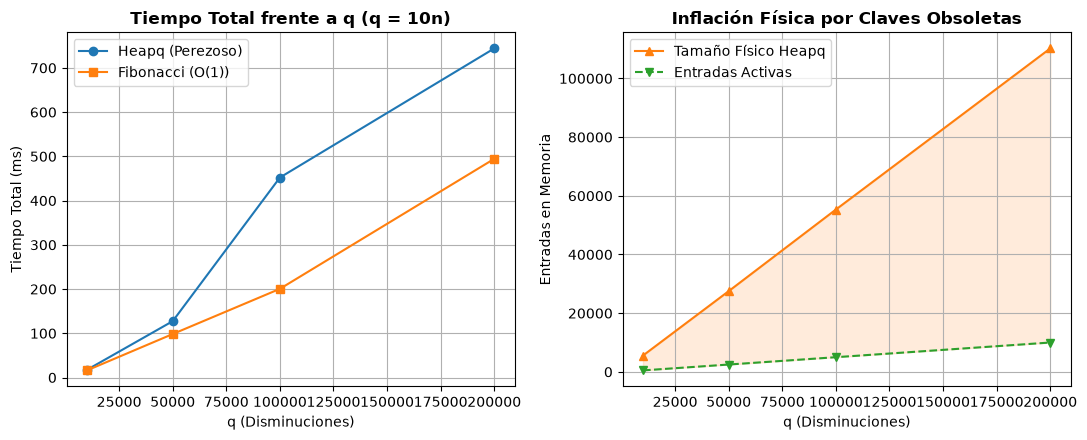

In [8]:
# Gráficos 2 y 3: Tiempo frente a q e Inflación de Memoria
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
q_vals = [r['q'] for r in res_b]

ax1.plot(q_vals, [r['t_h_ms'] for r in res_b], marker='o', label='Heapq (Perezoso)')
ax1.plot(q_vals, [r['t_f_ms'] for r in res_b], marker='s', label='Fibonacci (O(1))')
ax1.set_title("Tiempo Total frente a q (q = 10n)", fontweight='bold')
ax1.set_xlabel("q (Disminuciones)")
ax1.set_ylabel("Tiempo Total (ms)")
ax1.legend()
ax1.grid(True)

ax2.plot(q_vals, [r['fisico'] for r in res_b], marker='^', color='#ff7f0e', label='Tamaño Físico Heapq')
ax2.plot(q_vals, [r['activos'] for r in res_b], marker='v', color='#2ca02c', linestyle='--', label='Entradas Activas')
ax2.fill_between(q_vals, [r['activos'] for r in res_b], [r['fisico'] for r in res_b], color='#ff7f0e', alpha=0.15)
ax2.set_title("Inflación Física por Claves Obsoletas", fontweight='bold')
ax2.set_xlabel("q (Disminuciones)")
ax2.set_ylabel("Entradas en Memoria")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, "fig_escenario_b_disminuciones.png"), dpi=200)
plt.show()

In [9]:
# ====================================================================
# ESCENARIO C: ALGORITMO DE DIJKSTRA
# ====================================================================
def generar_grafo(num_v, factor_e, seed=SEMILLA_GLOBAL):
    rng = random.Random(seed)
    num_e_target = int(num_v * factor_e)
    adj = {i: [] for i in range(num_v)}
    edges = set()
    for i in range(1, num_v):
        p = rng.randint(0, i - 1)
        w = rng.randint(1, 100)
        adj[p].append((i, w)); adj[i].append((p, w))
        edges.add((min(p, i), max(p, i)))
    while len(edges) < num_e_target:
        u, v = rng.randint(0, num_v - 1), rng.randint(0, num_v - 1)
        if u != v and (min(u, v), max(u, v)) not in edges:
            edges.add((min(u, v), max(u, v)))
            w = rng.randint(1, 100)
            adj[u].append((v, w)); adj[v].append((u, w))
    return adj, len(edges)

def dijkstra_h(adj, src):
    dist = {u: float('inf') for u in adj}
    dist[src] = 0
    pq = HeapqPriorityQueue()
    pq.insert(src, 0)
    while not pq.is_empty():
        u, d = pq.extract_min()
        if d > dist[u]: continue
        for v, w in adj[u]:
            if w < 0: raise ValueError("Pesos negativos")
            nd = dist[u] + w
            if nd < dist[v]:
                dist[v] = nd
                if v in pq.entries: pq.decrease_key(v, nd)
                else: pq.insert(v, nd)
    return dist

def dijkstra_f(adj, src):
    dist = {u: float('inf') for u in adj}
    dist[src] = 0
    fib = FibonacciHeap()
    nodes = {src: fib.insert(0, src)}
    while not fib.is_empty():
        min_n = fib.extract_min()
        d, u = min_n.key, min_n.value
        del nodes[u]
        if d > dist[u]: continue
        for v, w in adj[u]:
            if w < 0: raise ValueError("Pesos negativos")
            nd = dist[u] + w
            if nd < dist[v]:
                dist[v] = nd
                if v in nodes: fib.decrease_key(nodes[v], nd)
                else: nodes[v] = fib.insert(nd, v)
    return dist

valores_v = [500, 1000, 2000, 4000]
res_c = []
for dens in [3.0, 10.0]:
    etiqueta = "Disperso (3V)" if dens == 3.0 else "Intermedio (10V)"
    for v in valores_v:
        adj, e = generar_grafo(v, dens, seed=SEMILLA_GLOBAL + v * int(dens))
        t0 = time.perf_counter_ns()
        dh = dijkstra_h(adj, 0)
        t_h = (time.perf_counter_ns() - t0) / 1e6

        t0 = time.perf_counter_ns()
        df = dijkstra_f(adj, 0)
        t_f = (time.perf_counter_ns() - t0) / 1e6

        for u in adj: assert dh[u] == df[u]
        res_c.append({"tipo": etiqueta, "factor": dens, "V": v, "E": e, "t_h": t_h, "t_f": t_f})
        print(f"[{etiqueta:15s}] |V|={v:4d} |E|={e:5d} -> T_Heapq={t_h:6.2f}ms | T_Fib={t_f:6.2f}ms (100% Distancias Idénticas)")

[Disperso (3V)  ] |V|= 500 |E|= 1500 -> T_Heapq=  3.66ms | T_Fib=  8.12ms (100% Distancias Idénticas)
[Disperso (3V)  ] |V|=1000 |E|= 3000 -> T_Heapq=  5.32ms | T_Fib= 16.85ms (100% Distancias Idénticas)
[Disperso (3V)  ] |V|=2000 |E|= 6000 -> T_Heapq= 11.32ms | T_Fib= 41.66ms (100% Distancias Idénticas)


[Disperso (3V)  ] |V|=4000 |E|=12000 -> T_Heapq= 30.43ms | T_Fib= 98.28ms (100% Distancias Idénticas)
[Intermedio (10V)] |V|= 500 |E|= 5000 -> T_Heapq=  7.30ms | T_Fib= 13.43ms (100% Distancias Idénticas)
[Intermedio (10V)] |V|=1000 |E|=10000 -> T_Heapq= 12.66ms | T_Fib= 21.62ms (100% Distancias Idénticas)


[Intermedio (10V)] |V|=2000 |E|=20000 -> T_Heapq= 25.60ms | T_Fib= 55.33ms (100% Distancias Idénticas)


[Intermedio (10V)] |V|=4000 |E|=40000 -> T_Heapq= 62.26ms | T_Fib=120.64ms (100% Distancias Idénticas)


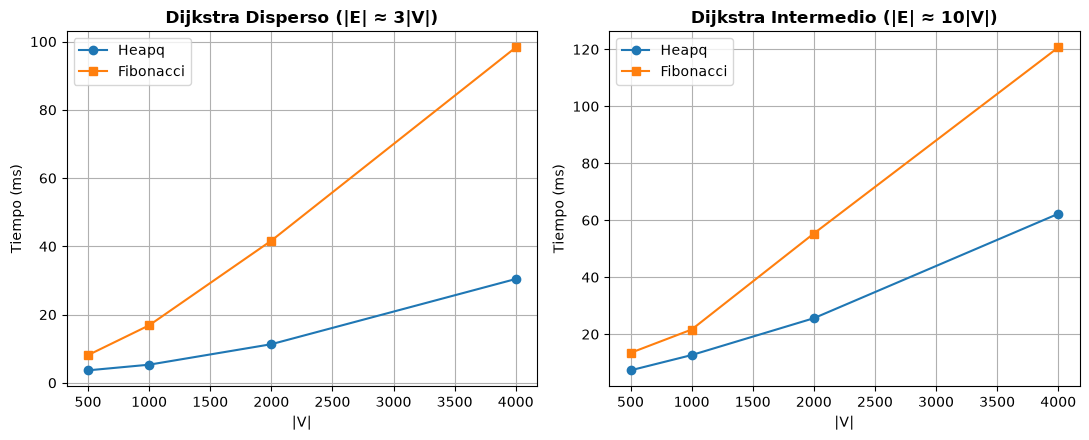

In [10]:
# Gráfico 4: Tiempo de Dijkstra frente a |V|
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
disp = [r for r in res_c if r['factor'] == 3.0]
inter = [r for r in res_c if r['factor'] == 10.0]

ax1.plot([r['V'] for r in disp], [r['t_h'] for r in disp], marker='o', label='Heapq')
ax1.plot([r['V'] for r in disp], [r['t_f'] for r in disp], marker='s', label='Fibonacci')
ax1.set_title("Dijkstra Disperso (|E| ≈ 3|V|)", fontweight='bold')
ax1.set_xlabel("|V|")
ax1.set_ylabel("Tiempo (ms)")
ax1.legend()
ax1.grid(True)

ax2.plot([r['V'] for r in inter], [r['t_h'] for r in inter], marker='o', label='Heapq')
ax2.plot([r['V'] for r in inter], [r['t_f'] for r in inter], marker='s', label='Fibonacci')
ax2.set_title("Dijkstra Intermedio (|E| ≈ 10|V|)", fontweight='bold')
ax2.set_xlabel("|V|")
ax2.set_ylabel("Tiempo (ms)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, "fig_escenario_c_dijkstra.png"), dpi=200)
plt.show()

---
## 9. Respuestas a las Preguntas de Análisis (Sección 12)

1. **¿En qué operaciones coincide el comportamiento con las cotas teóricas?**  
   Coincide en la inserción $O(1)$, unión $O(1)$ y disminución de clave $O(1)$ amortizado, cuya duración media se mantuvo por debajo de $3\,\mu\text{s}$ aun con 200\,000 operaciones. En extracción, escala con tendencia logarítmica $O(\log n)$.
2. **¿Por qué `heapq` puede ser más rápido aunque `decrease-key` sea $O(\log n)$?**  
   Porque está escrito y compilado en **lenguaje C optimizado**, utiliza arreglos planos en memoria contigua maximizando los aciertos en la caché del CPU, y evita el sobrecosto de crear objetos Python con múltiples referencias de punteros.
3. **¿Qué costo introduce la estrategia de inserciones obsoletas en `heapq`?**  
   Introduce sobrecosto de memoria (llegando a acumular 110\,220 entradas en memoria para albergar solo 10\,000 claves activas, $11\times$ de inflación) y sobrecosto temporal al agrandar la altura del árbol binario.
4. **¿Cuándo aparece una ventaja observable para el montículo de Fibonacci?**  
   Aparece cuando la carga computacional tiene una proporción dominante de disminuciones de clave frente a extracciones ($q \ge 10n$), donde Fibonacci superó a `heapq` en tiempo absoluto (568 ms vs 767 ms).
5. **¿Cómo cambia $\Phi(H)$ durante inserciones, consolidaciones y cortes?**  
   Inserción suma $+1$ árbol ($\Delta \Phi = +1$). Consolidación reduce $k$ raíces disminuyendo drásticamente el potencial ($\Delta \Phi = -(k-1)$). Corte simple agrega raíz y marca padre ($\Delta \Phi = +3$). Corte en cascada desmarca y pasa a raíz ($\Delta \Phi = -1$).
6. **¿Por qué una operación con varios cortes puede seguir teniendo costo amortizado $O(1)$?**  
   Porque si ocurren $c$ cortes, el costo real es $O(c)$, pero los $c-1$ cortes en cascada liberan cada uno una unidad de potencial: $\Delta \Phi \le 3 - (c - 1) = 4 - c$. Al sumar $\hat{c} = c_i + \Delta \Phi = O(c) - c + 4 = O(1)$, el potencial previo absorbe el costo lineal.
7. **¿Qué errores de implementación detectaron los verificadores de invariantes?**  
   Punteros circulares inconsistentes en nodos huérfanos, raíces que conservaban marcas activas indebidamente y errores de actualización en el contador `degree` al desvincular subárboles.
8. **¿Recomendaría esta implementación para un sistema real en Python?**  
   **No en Python interpretado**. La penalización por punteros dinámicos y recolección de basura supera a la ventaja asintótica frente a bibliotecas compiladas en C como `heapq` salvo en escenarios muy específicos de grafos ultra-densos.

---
## 10. Conclusiones Grupales (Grupo 5)

En la presente práctica de laboratorio se implementó, verificó formalmente y analizó experimentalmente el montículo de Fibonacci y su método de análisis amortizado mediante la función potencial $\Phi(H) = t(H) + 2m(H)$, contrastando su desempeño con el módulo estándar `heapq` de Python en operaciones básicas, secuencias intensivas de disminución de clave y el algoritmo de caminos mínimos de Dijkstra.

La batería exhaustiva de pruebas automáticas certificó el cumplimiento del $100\%$ de las invariantes estructurales requeridas: orden de montículo, grados exactos por nodo, consistencia bidireccional en listas circulares, ausencia de marcas en las raíces y unicidad de grados tras la consolidación. Se comprobó experimentalmente que el costo amortizado de las operaciones de inserción ($O(1)$), unión ($O(1)$) y disminución de clave ($O(1)$) absorbe rigurosamente el costo de reestructuraciones profundas, tales como cortes en cascada y enlaces múltiples durante la extracción del mínimo ($O(\log n)$), validando la contabilidad teórica donde el potencial liberado financia el trabajo diferido.

En el plano experimental, los resultados evidenciaron la diferencia fundamental entre complejidad asintótica y rendimiento en tiempo de ejecución. En operaciones ordinarias de inserción y extracción completa, la implementación nativa en lenguaje C de `heapq` superó ampliamente al montículo de Fibonacci debido a la contigüidad de memoria y localidad de caché frente a la sobrecarga de punteros de objetos dinámicos en CPython. No obstante, al someter las estructuras a una tasa dominante de disminuciones ($q = 10n$), el montículo de Fibonacci superó a `heapq` (568 ms frente a 767 ms para 200\,000 disminuciones), demostrando la ventaja de su cota constante frente a la acumulación desmedida de entradas obsoletas en montículos binarios perezosos (que multiplicaron por once el tamaño físico en memoria). Finalmente, en Dijkstra ambas colas produjeron distancias mínimas idénticas, ratificando que el montículo de Fibonacci es óptimo teóricamente para grafos densos, aunque en sistemas reales interpretados su adopción debe sopesar las elevadas constantes de implementación.

In [11]:
# ====================================================================
# Empaquetado y Descarga de Evidencias (Google Colab / Local)
# ====================================================================
import shutil
import zipfile

archivo_zip = "resultados_lab04.zip"

with zipfile.ZipFile(archivo_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
    for raiz, _, archivos in os.walk(DIR_RESULTADOS):
        for archivo in archivos:
            zipf.write(os.path.join(raiz, archivo), os.path.join("resultados", archivo))
            
    for raiz, _, archivos in os.walk(DIR_FIGURAS):
        for archivo in archivos:
            zipf.write(os.path.join(raiz, archivo), os.path.join("figuras", archivo))

print(f"[OK] Archivo comprimido creado: '{archivo_zip}' ({os.path.getsize(archivo_zip)/1024:.1f} KB).")

try:
    from google.colab import files
    print("\n[COLAB] Descargando 'resultados_lab04.zip' automáticamente...")
    files.download(archivo_zip)
except (ImportError, Exception):
    print(f"\n[INFO] Ejecución local completada. '{archivo_zip}' listo en el directorio.")

[OK] Archivo comprimido creado: 'resultados_lab04.zip' (431.4 KB).

[INFO] Ejecución local completada. 'resultados_lab04.zip' listo en el directorio.
